In [2]:
!pip install transformers --quiet
!pip install opendatasets --quiet

# Workaround for Python 3.13 missing 'cgi' module required by opendatasets
import sys
try:
    import cgi
except ModuleNotFoundError:
    import html
    import sys
    from types import ModuleType
    cgi = ModuleType("cgi")
    cgi.escape = html.escape
    sys.modules["cgi"] = cgi

import opendatasets as od
od.download("https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: muhammadalirehman
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/rmisra/news-headlines-dataset-for-sarcasm-detection


100%|██████████| 3.30M/3.30M [00:01<00:00, 2.38MB/s]


In [32]:
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
device = "cuda" if torch.cuda.is_available() else "cpu"
print("available ", device)

available  cuda


In [37]:
data_df = pd.read_json("/content/news-headlines-dataset-for-sarcasm-detection/Sarcasm_Headlines_Dataset.json" , lines = True)
data_df.dropna(inplace=True)
data_df.drop_duplicates(inplace=True)
data_df.drop(["article_link"],inplace=True , axis = 1)
print(data_df.shape)
print(data_df.head())

(26708, 2)
                                            headline  is_sarcastic
0  former versace store clerk sues over secret 'b...             0
1  the 'roseanne' revival catches up to our thorn...             0
2  mom starting to fear son's web series closest ...             1
3  boehner just wants wife to listen, not come up...             1
4  j.k. rowling wishes snape happy birthday in th...             0


In [38]:
X_train,X_test, y_train,y_test = train_test_split(np.array(data_df["headline"]),np.array(data_df["is_sarcastic"]),test_size=0.3)
X_val,X_test, y_val,y_test = train_test_split(X_test,y_test,test_size=0.5)
print("training size :",X_train.shape[0],"which is ",round(X_train.shape[0]/data_df.shape[0],4)*100,"%")
print("validation size :",X_val.shape[0],"which is ",round(X_val.shape[0]/data_df.shape[0],4)*100,"%")
print("testing size :",X_test.shape[0],"which is ",round(X_test.shape[0]/data_df.shape[0],4)*100,"%")

training size : 18695 which is  70.0 %
validation size : 4006 which is  15.0 %
testing size : 4007 which is  15.0 %


In [39]:
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")
bert_model = AutoModel.from_pretrained("google-bert/bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [40]:
class dataset(Dataset):
  def __init__(self,X,Y):
    self.X = [tokenizer(x,
                        max_length = 100,
                        truncation=True,
                        padding = "max_length",
                        return_tensors = "pt").to(device)
                        for x in X
              ]
    self.Y  = torch.tensor(Y,dtype =torch.float32).to(device)
  def __len__(self):
    return len(self.X)
  def __getitem__(self,idx):
    text = self.X[idx] , self.Y[idx]
    return text

training_data = dataset(X_train,y_train)
validation_data = dataset(X_val,y_val)
testing_data = dataset(X_test,y_test)

In [41]:
BATCH_SIZE = 32
EPOCHS = 10
LR = 1e-4

In [42]:
train_dataloader = DataLoader(training_data,batch_size=BATCH_SIZE,shuffle=True)
validation_dataloader = DataLoader(validation_data,batch_size=BATCH_SIZE,shuffle=True)
testing_dataloader = DataLoader(testing_data,batch_size=BATCH_SIZE,shuffle=True)

In [43]:
class MyModel(nn.Module):
  def __init__(self,bert):
    super(MyModel,self).__init__()

    self.bert = bert
    self.dropout = nn.Dropout(0.25)
    self.linear1 = nn.Linear (768,384)
    self.linear2 = nn.Linear(384,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,input_ids , attention_mask):
    pooled_output = self.bert(input_ids = input_ids , attention_mask = attention_mask, return_dict = False)[0][:,0,:]
    output = self.linear1(pooled_output)
    output = self.dropout(output)
    output = self.linear2(output)
    output = self.sigmoid(output)
    return output

In [44]:
for param in bert_model.parameters():
  param.requires_grad = False
model = MyModel(bert_model).to(device)

In [45]:
criterian = nn.BCELoss()
optimzer = Adam(model.parameters(), lr=LR)

In [47]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
  total_loss_train = 0
  total_acc_train = 0
  total_loss_validation = 0
  total_acc_validation = 0
  model.train()
  for idx , data in enumerate(train_dataloader):
    inputs , label = data
    inputs.to(device)
    label.to(device)

    prediction = model(inputs["input_ids"].squeeze(1),inputs["attention_mask"].squeeze(1)).squeeze(1)
    batch_loss = criterian(prediction,label)
    total_loss_train += batch_loss.item()
    acc = (prediction.round() == label).sum().item()
    total_acc_train += acc
    batch_loss.backward()
    optimzer.step()
    optimzer.zero_grad()

  model.eval()
  with torch.no_grad():
    for idx , data in enumerate(validation_dataloader):
      inputs , labels = data
      inputs.to(device)
      labels.to(device)
      prediction = model(inputs["input_ids"].squeeze(1),inputs["attention_mask"].squeeze(1)).squeeze(1)
      batch_loss = criterian(prediction,labels)
      total_loss_validation += batch_loss.item()
      acc = (prediction.round() == labels).sum().item()
      total_acc_validation += acc

  total_loss_train_plot.append(round(total_loss_train/1000,4))
  total_loss_validation_plot.append(round(total_loss_validation/1000,4))
  total_acc_train_plot.append(round((total_acc_train/training_data.__len__()) *100,4))
  total_acc_validation_plot.append(round((total_acc_validation/validation_data.__len__())*100,4))
  print(f"""
  Epoch no. {epoch+1}
  training loss : {round(total_loss_train/1000,4)},
  Training Accuracy : {round((total_acc_train/training_data.__len__()) *100,4)}%
  validation loss : {round(total_loss_validation/1000,4)},
  Validation Accuracy : {round((total_acc_validation/validation_data.__len__())*100,4)}%
  """)


  Epoch no. 1
  training loss : 0.2388,
  Training Accuracy : 82.0433%
  validation loss : 0.0428,
  Validation Accuracy : 85.7963%
  

  Epoch no. 2
  training loss : 0.2278,
  Training Accuracy : 83.0168%
  validation loss : 0.0413,
  Validation Accuracy : 86.4453%
  

  Epoch no. 3
  training loss : 0.2262,
  Training Accuracy : 82.9687%
  validation loss : 0.0409,
  Validation Accuracy : 86.2456%
  

  Epoch no. 4
  training loss : 0.2231,
  Training Accuracy : 83.3966%
  validation loss : 0.0395,
  Validation Accuracy : 87.1443%
  

  Epoch no. 5
  training loss : 0.2216,
  Training Accuracy : 83.6587%
  validation loss : 0.0395,
  Validation Accuracy : 87.1942%
  

  Epoch no. 6
  training loss : 0.2174,
  Training Accuracy : 83.8887%
  validation loss : 0.0406,
  Validation Accuracy : 86.3455%
  

  Epoch no. 7
  training loss : 0.2216,
  Training Accuracy : 83.5411%
  validation loss : 0.0388,
  Validation Accuracy : 87.344%
  

  Epoch no. 8
  training loss : 0.2206,
  Traini

In [50]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0

  for idx , data in enumerate(testing_dataloader):
    inputs , label = data
    inputs.to(device)
    label.to(device)

    prediction = model(inputs["input_ids"].squeeze(1),inputs["attention_mask"].squeeze(1)).squeeze(1)
    batch_loss = criterian(prediction,label)
    total_loss_test += batch_loss.item()
    acc = (prediction.round() == label).sum().item()

    total_acc_test +=acc
print(f"Accuracy score on testing Data is :{round((total_acc_train/training_data.__len__()) *100,4)}")

Accuracy score on testing Data is :83.8299


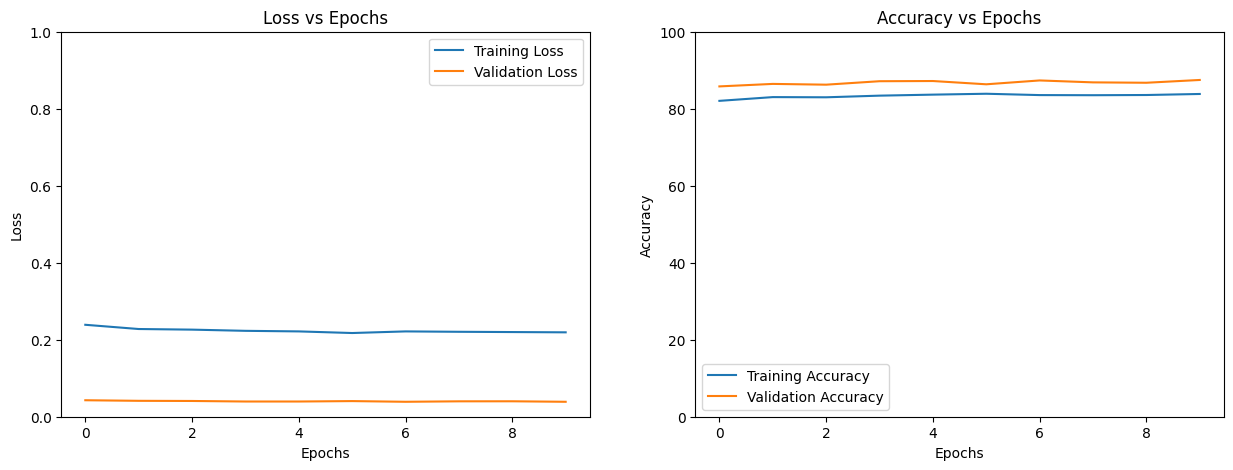

In [57]:
fig , axis = plt.subplots(1,2,figsize=(15,5))
axis[0].plot(total_loss_train_plot,label="Training Loss")
axis[0].plot(total_loss_validation_plot,label="Validation Loss")
axis[0].set_title("Loss vs Epochs")
axis[0].set_xlabel("Epochs")
axis[0].set_ylabel("Loss")
axis[0].set_ylim([0,1])
axis[0].legend()

axis[1].plot(total_acc_train_plot,label="Training Accuracy")
axis[1].plot(total_acc_validation_plot,label="Validation Accuracy")
axis[1].set_title("Accuracy vs Epochs")
axis[1].set_xlabel("Epochs")
axis[1].set_ylabel("Accuracy")
axis[1].set_ylim([0,100])
axis[1].legend()
plt.show()